In [2]:
import cv2
import numpy as np
from skimage.feature.texture import graycomatrix, graycoprops
import matplotlib.pyplot as plt

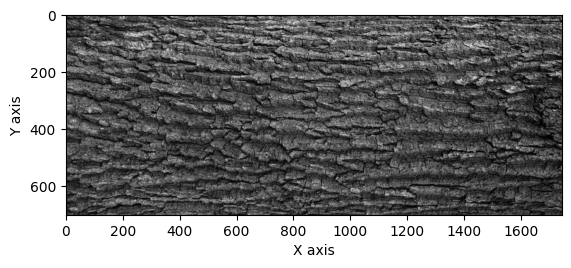

In [3]:
bw = cv2.imread('../assets/Picture1.jpg', 0)

plt.imshow(bw, cmap='gray')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.show()

In [20]:
GLCM_vertical_ski = graycomatrix(bw, distances=[1], angles=[np.pi/2], levels=256, normed=False)
energy = graycoprops(GLCM_vertical_ski, 'energy')
entropy= graycoprops(GLCM_vertical_ski, 'entropy')
contrast = graycoprops(GLCM_vertical_ski, 'contrast')
homogeneity = graycoprops(GLCM_vertical_ski, 'homogeneity')

print("Energy: ", energy)
print("Entropy: ", entropy)
print("Contrast: ", contrast)
print("Homogeneity: ", homogeneity)

print("shape",GLCM_vertical_ski.shape)
print(GLCM_vertical_ski)

Energy:  [[0.01299103]]
Entropy:  [[9.02709793]]
Contrast:  [[233.60898577]]
Homogeneity:  [[0.09316467]]
shape (256, 256, 1, 1)
[[[[248]]

  [[131]]

  [[144]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]


 [[[145]]

  [[102]]

  [[119]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]


 [[[127]]

  [[112]]

  [[128]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]


 ...


 [[[  0]]

  [[  0]]

  [[  0]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]


 [[[  0]]

  [[  0]]

  [[  0]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]


 [[[  0]]

  [[  0]]

  [[  0]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]]


In [5]:
def manual_vertical_glcm_fn(image, levels=256):
    glcm = np.zeros((levels, levels), dtype=int)
    h, w = image.shape
    for y in range(h - 1): 
        for x in range(w):
            i = image[y, x]
            j = image[y + 1, x]
            glcm[i, j] += 1
    # glcm = glcm / glcm.sum()        
    return glcm

In [ ]:
manual_vertical_glcm=manual_vertical_glcm_fn(bw, levels=256)


print("Manual GLCM shape:", manual_vertical_glcm.shape)
print(manual_vertical_glcm) 

ValueError: The parameter `P` must be a 4-dimensional array

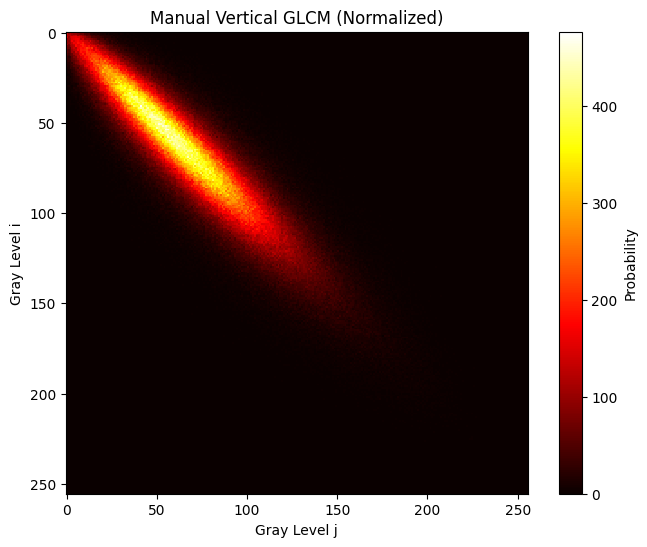

In [7]:
plt.figure(figsize=(8, 6))
plt.imshow(manual_vertical_glcm, cmap='hot', interpolation='nearest')
plt.title('Manual Vertical GLCM (Normalized)')
plt.xlabel('Gray Level j')
plt.ylabel('Gray Level i')
plt.colorbar(label='Probability')
plt.show()

In [21]:
GLCM_horizontal_ski = graycomatrix(bw, distances=[1], angles=[0], levels=256, normed=False)
energy = graycoprops(GLCM_horizontal_ski, 'energy')
entropy= graycoprops(GLCM_horizontal_ski, 'entropy')
contrast = graycoprops(GLCM_horizontal_ski, 'contrast')
homogeneity = graycoprops(GLCM_horizontal_ski, 'homogeneity')
correlation = graycoprops(GLCM_horizontal_ski, 'correlation')

print("Energy: ", energy)
print("Entropy: ", entropy)
print("Contrast: ", contrast)
print("Homogeneity: ", homogeneity)
print("Correlation: ", correlation)

print("shape", GLCM_horizontal_ski.shape)
print(GLCM_horizontal_ski)

Energy:  [[0.01478692]]
Entropy:  [[8.7786305]]
Contrast:  [[141.80950524]]
Homogeneity:  [[0.11983247]]
Correlation:  [[0.94576706]]
shape (256, 256, 1, 1)
[[[[430]]

  [[214]]

  [[191]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]


 [[[211]]

  [[151]]

  [[150]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]


 [[[210]]

  [[147]]

  [[196]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]


 ...


 [[[  0]]

  [[  0]]

  [[  0]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]


 [[[  0]]

  [[  0]]

  [[  0]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]


 [[[  0]]

  [[  0]]

  [[  0]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]]


In [9]:
def manual_horizontal_glcm_fn(image, levels=256):
    glcm = np.zeros((levels, levels), dtype=int)
    h, w = image.shape
    for y in range(h): 
        for x in range(w - 1):
            i = image[y, x]
            j = image[y, x + 1]
            glcm[i, j] += 1
    # glcm = glcm / glcm.sum()        
    return glcm

In [10]:
manual_horizontal_glcm=manual_horizontal_glcm_fn(bw, levels=256)
print("Manual Horizontal GLCM shape:", manual_horizontal_glcm.shape)
print(manual_horizontal_glcm)

Manual Horizontal GLCM shape: (256, 256)
[[430 214 191 ...   0   0   0]
 [211 151 150 ...   0   0   0]
 [210 147 196 ...   0   0   0]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]


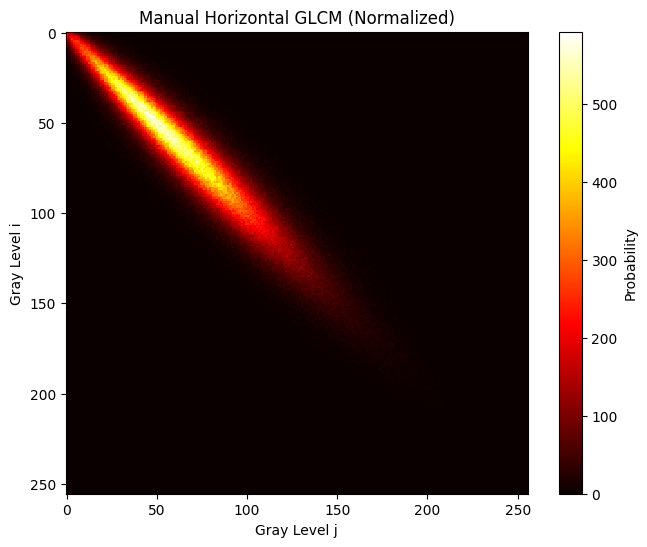

In [11]:
plt.figure(figsize=(8, 6))
plt.imshow(manual_horizontal_glcm, cmap='hot', interpolation='nearest')
plt.title('Manual Horizontal GLCM (Normalized)')
plt.xlabel('Gray Level j')
plt.ylabel('Gray Level i')
plt.colorbar(label='Probability')
plt.show()

In [12]:
GLCM_diagonal_ski = graycomatrix(bw, distances=[1], angles=[np.pi/4], levels=256)
print("shape",GLCM_diagonal_ski.shape)
print(GLCM_diagonal_ski)

shape (256, 256, 1, 1)
[[[[160]]

  [[105]]

  [[114]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]


 [[[ 88]]

  [[ 88]]

  [[ 93]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]


 [[[112]]

  [[ 92]]

  [[103]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]


 ...


 [[[  0]]

  [[  0]]

  [[  0]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]


 [[[  0]]

  [[  0]]

  [[  0]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]


 [[[  0]]

  [[  0]]

  [[  0]]

  ...

  [[  0]]

  [[  0]]

  [[  0]]]]


In [13]:
def manual_diagonal_glcm_fn(image, levels=256):
    glcm = np.zeros((levels, levels), dtype=int)
    h, w = image.shape
    for y in range(h - 1): 
        for x in range(w - 1):
            i = image[y, x]
            j = image[y + 1, x + 1]
            glcm[i, j] += 1
    # glcm = glcm / glcm.sum()        
    return glcm

In [14]:
manual_diagonal_glcm=manual_diagonal_glcm_fn(bw, levels=256)
print("Manual Diagonal GLCM shape:", manual_diagonal_glcm.shape)
print(manual_diagonal_glcm)

Manual Diagonal GLCM shape: (256, 256)
[[160 105 114 ...   0   0   0]
 [ 88  88  93 ...   0   0   0]
 [112  92 103 ...   0   0   0]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]


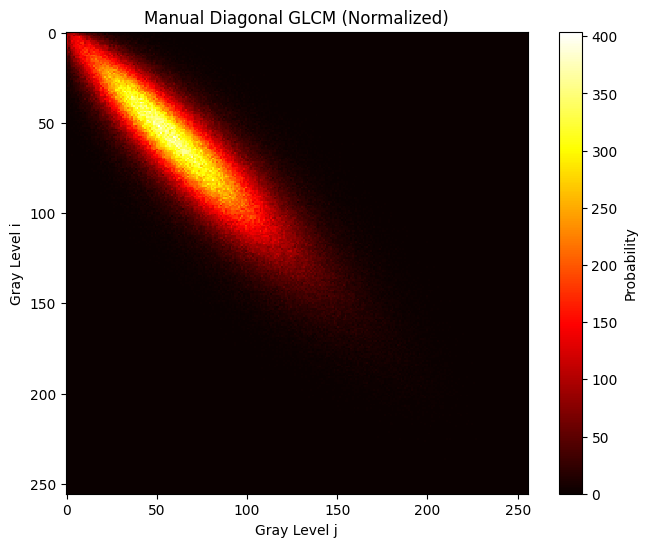

In [15]:
plt.figure(figsize=(8, 6))
plt.imshow(manual_diagonal_glcm, cmap='hot', interpolation='nearest')
plt.title('Manual Diagonal GLCM (Normalized)')
plt.xlabel('Gray Level j')
plt.ylabel('Gray Level i')
plt.colorbar(label='Probability')
plt.show()